In [6]:
import torch
import torch.optim as optim
import torch.nn as nn
import pandas as pd

from database.mongo import get_collection
from ia.LSTM.preprocess import preprocess_data
from ia.LSTM.dataloader import create_dataloaders
from ia.LSTM.LSTM import LSTM

from ia.LSTM.model_functions.train import train_model
from ia.LSTM.model_functions.test import test_model

In [7]:

n_epochs = 200
batch_size = 64
hidden_size = 128
learning_rate = 0.00015
TEST_SIZE = 0.2
patience = 50

# Leitura a cada 15 minutos
passo = 4 * 24 * 7
future_steps = 4 * 12


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [8]:
dados = list(get_collection().find())
df = pd.DataFrame(dados)
if df.empty:
    raise ValueError("Não há dados suficientes para treinar o modelo.")
df.drop(columns=["_id"], inplace=True)

df, X_train, X_test, y_train, y_test, scaler, le = preprocess_data(
    df, passo=passo, future_steps=future_steps, test_size=TEST_SIZE
)
train_loader, test_loader = create_dataloaders(
    X_train, y_train, X_test, y_test, batch_size
)

input_size = X_train.shape[2]
model = LSTM(
    input_size=input_size,
    future_steps=future_steps,
    passo=passo,
    hidden_size=hidden_size,
).to(device)

loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

2025-06-25 10:59:23.796 | INFO     | ia.LSTM.model_functions.train:train_model:39 - Epoch 1/200 - Loss: 0.3218
2025-06-25 11:00:11.299 | INFO     | ia.LSTM.model_functions.train:train_model:39 - Epoch 2/200 - Loss: 0.1450
2025-06-25 11:01:09.658 | INFO     | ia.LSTM.model_functions.train:train_model:39 - Epoch 3/200 - Loss: 0.0811
2025-06-25 11:02:09.001 | INFO     | ia.LSTM.model_functions.train:train_model:39 - Epoch 4/200 - Loss: 0.0799
2025-06-25 11:03:09.026 | INFO     | ia.LSTM.model_functions.train:train_model:39 - Epoch 5/200 - Loss: 0.0795
2025-06-25 11:04:09.172 | INFO     | ia.LSTM.model_functions.train:train_model:39 - Epoch 6/200 - Loss: 0.0791
2025-06-25 11:05:09.123 | INFO     | ia.LSTM.model_functions.train:train_model:39 - Epoch 7/200 - Loss: 0.0789
2025-06-25 11:06:08.584 | INFO     | ia.LSTM.model_functions.train:train_model:39 - Epoch 8/200 - Loss: 0.0791
2025-06-25 11:07:07.539 | INFO     | ia.LSTM.model_functions.train:train_model:39 - Epoch 9/200 - Loss: 0.0787
2

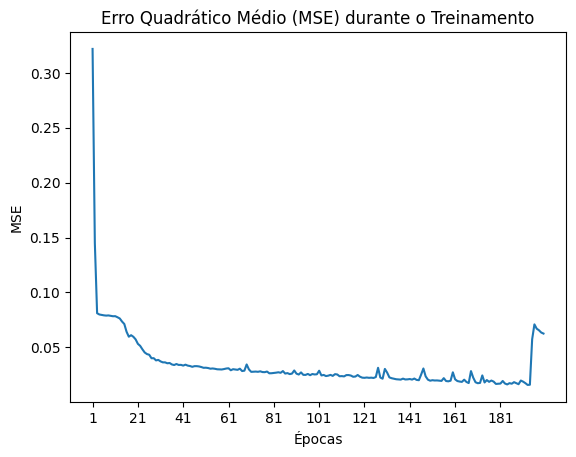

In [9]:
train_model(model, train_loader, loss_fn, optimizer, n_epochs, patience, device, plot_loss=True)

RMSE: 28.7213
MAE: 23.4012
WAPE: 0.4142


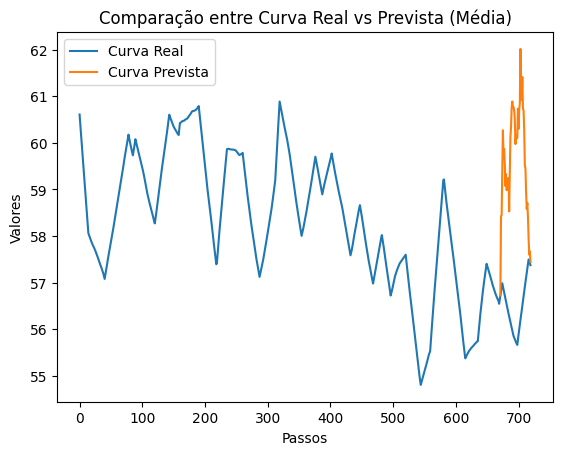

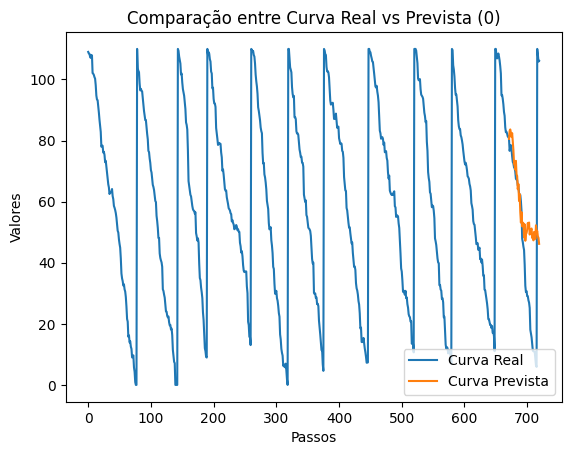

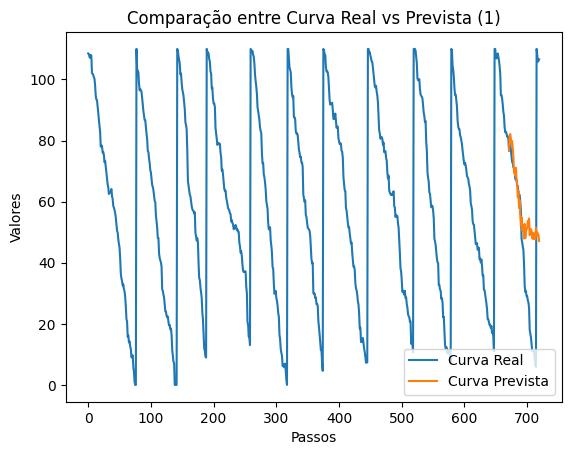

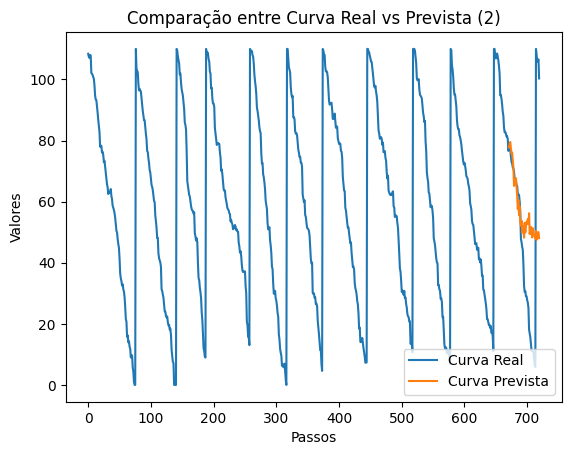

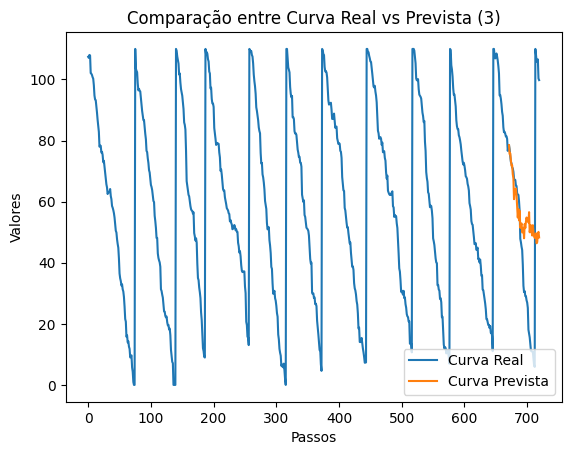

In [10]:
test_model(model, test_loader, scaler, device=device, show=True)